
```
# 관련 코드 및 과정 해석은 AI의 도움을 받음
# 하지만 생각의 과정 및 로직은 본 수행자에게 있음
# README.md를 통해 과정 및 결과 요약 정리 완료
```

## 각 센서값은 평균치로 계산

In [ ]:
import os
import json
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor


DATA_ROOT = "./data/Training"


# [추가 1] JSON 파일 하나를 처리하는 함수
def process_json(json_file):
    records = []

    folder_name = json_file.parent.name

    if "불량" in folder_name:
        label = 1
    elif "정상" in folder_name:
        label = 0
    else:
        return records

    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    for sensor_block in data.get("sensor_data", []):
        seq = sensor_block.get("sensor_sequence", [])

        if not seq:
            continue

        for row in seq:
            records.append({
                "file_name": json_file.name,
                "folder": folder_name,
                "timestamp": row["timestamp"],
                "temperature": row["temperature"],
                "humidity": row["humidity"],
                "vibration": row["vibration"],
                "acceleration": row["acceleration"],
                "noise": row["noise"],
                "양불량": label
            })

    return records


# 전체 JSON 파일 목록
json_files = list(Path(DATA_ROOT).rglob("*.json"))

print(f"전체 JSON 파일: {len(json_files):,}개")


# [수정 2] ProcessPoolExecutor → ThreadPoolExecutor
records = []

with ThreadPoolExecutor(max_workers=8) as executor:

    results = executor.map(process_json, json_files)

    # [수정 3] tqdm으로 진행상황 확인
    for result in tqdm(
        results,
        total=len(json_files),
        desc="JSON 처리"
    ):
        records.extend(result)


# DataFrame 생성
df = pd.DataFrame(records)

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.drop(columns=["file_name", "folder"])

print(df.shape)
print(df["양불량"].value_counts())

전체 JSON 파일: 41,085개


JSON 처리:   0%|          | 0/41085 [00:00<?, ?it/s]

(205425, 7)
양불량
1    129615
0     75810
Name: count, dtype: int64


## 센서값 분포

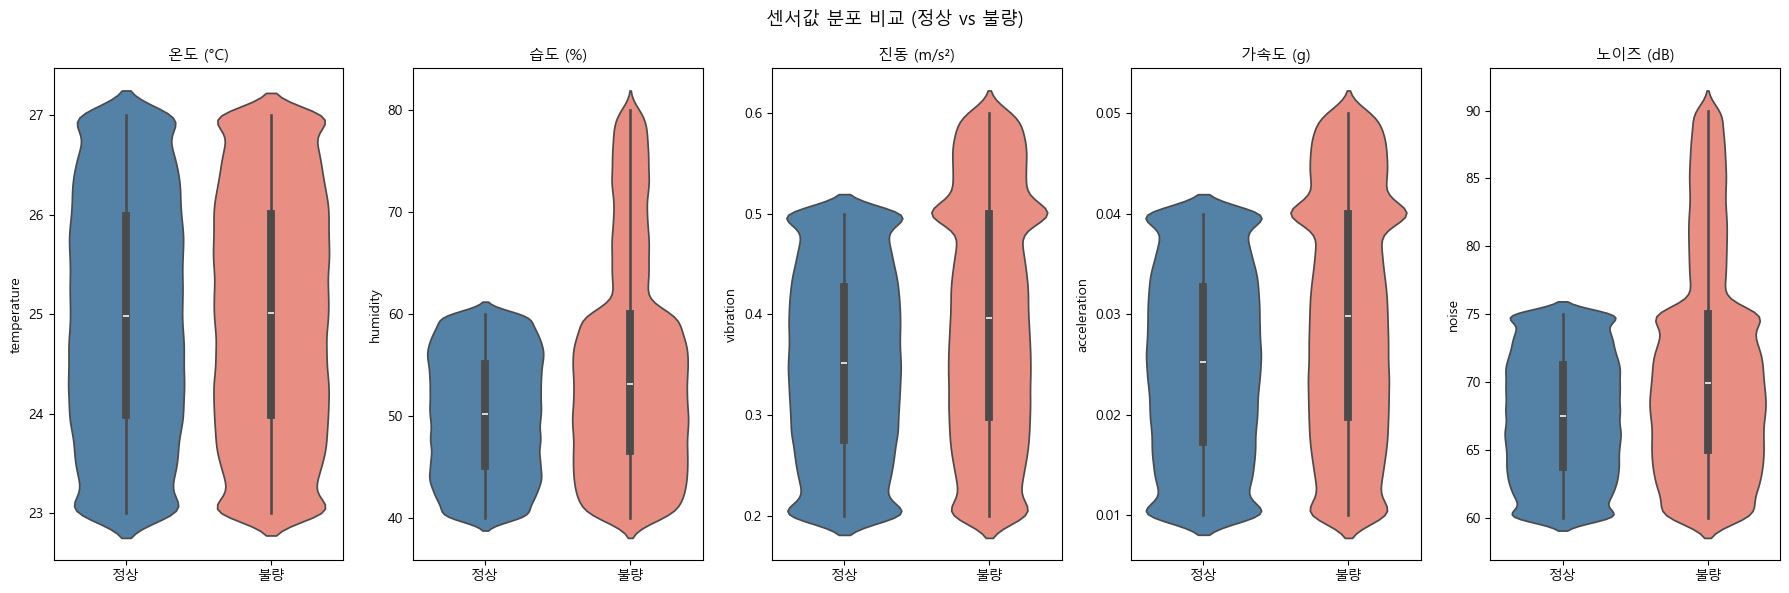

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

sensors = ["temperature", "humidity", "vibration", "acceleration", "noise"]
sensor_labels = {
    "temperature":  "온도 (°C)",
    "humidity":     "습도 (%)",
    "vibration":    "진동 (m/s²)",
    "acceleration": "가속도 (g)",
    "noise":        "노이즈 (dB)"
}

fig, axes = plt.subplots(1, len(sensors), figsize=(18, 6))

for ax, sensor in zip(axes, sensors):
    sns.violinplot(
        data=df,
        x="양불량",
        y=sensor,
        hue="양불량",         # 추가
        palette=["steelblue", "salmon"],
        inner="box",
        legend=False,         # 추가
        ax=ax
    )
    ax.set_title(sensor_labels[sensor], fontsize=11)
    ax.set_xlabel("")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["정상", "불량"])

fig.suptitle("센서값 분포 비교 (정상 vs 불량)", fontsize=13)
plt.tight_layout()
plt.show()
fig.savefig("violin_plot.png", dpi=150, bbox_inches='tight')

## 로지스틱 회귀

In [3]:
import statsmodels.api as sm

X = df.drop(columns=["timestamp", "양불량"], axis=1)
y = df["양불량"]
X = sm.add_constant(X)

model = sm.Logit(y, X).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.492542
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                    양불량   No. Observations:               205425
Model:                          Logit   Df Residuals:                   205419
Method:                           MLE   Df Model:                            5
Date:                Fri, 18 Sep 2026   Pseudo R-squ.:                  0.2520
Time:                        10:02:20   Log-Likelihood:            -1.0118e+05
converged:                       True   LL-Null:                   -1.3526e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -19.9425      0.153   -129.958      0.000     -20.243     -19.642
temperature      0.0132      0.005      2.865      0.004       0.004       0.022
humidity         0.1061      0.001    147.704      0.000       0.105       0.107
vibration        7.2626      0.054    134.715      0.000       7.157       7.368
acceleration    73.9257      0.539    137.221      0.000      72.870      74.982
noise            0.1420      0.001    150.328      0.000       0.140       0.144
================================================================================
"""

- 사전에, 센서별로 mean / std / min / max / range로 통계 집계
- 그 후, 통계 집계된 데이터로 정밀 로지스틱 회귀 분석

In [4]:
import os
import json
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor  # [추가] 병렬처리


DATA_ROOTS = [
    "../data/Training",
    "../data/Validation"
]


# [추가] JSON 파일 1개 처리
def process_json(json_file):
    folder_name = json_file.parent.name

    if "불량" in folder_name:
        label = 1
    elif "정상" in folder_name:
        label = 0
    else:
        return None

    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    records = []

    for sensor_block in data.get("sensor_data", []):
        seq = sensor_block.get("sensor_sequence", [])

        if not seq:
            continue

        df_seq = pd.DataFrame(seq)

        record = {
            "file_name": json_file.name,
            "folder": folder_name,
        }

        for sensor in ["temperature", "humidity", "vibration", "acceleration", "noise"]:
            record[f"{sensor}_mean"] = df_seq[sensor].mean()
            record[f"{sensor}_std"] = df_seq[sensor].std()

        record["양불량"] = label
        records.append(record)

    return records


# [수정] 전체 JSON 파일 목록
json_files = []

for DATA_ROOT in DATA_ROOTS:
    json_files.extend(Path(DATA_ROOT).rglob("*.json"))

print(f"전체 JSON 파일: {len(json_files):,}개")


records = []

# [추가] 병렬처리 + 진행률
with ThreadPoolExecutor(max_workers=8) as executor:
    results = executor.map(process_json, json_files)

    for result in tqdm(results, total=len(json_files), desc="JSON 처리"):
        if result:
            records.extend(result)


df_file = pd.DataFrame(records)

print(df_file.shape)
print(df_file["양불량"].value_counts())

전체 JSON 파일: 46,220개


JSON 처리: 100%|██████████| 46220/46220 [02:02<00:00, 378.50it/s] 


(46220, 13)
양불량
1    29162
0    17058
Name: count, dtype: int64


In [5]:
import statsmodels.api as sm

# 피처 선택
feature_cols = [col for col in df_file.columns 
                if col.endswith("_mean") or col.endswith("_std")]

X = df_file[feature_cols]
y = df_file["양불량"]

X = sm.add_constant(X)

model = sm.Logit(y, X)
result = model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.473045
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                    양불량   No. Observations:                46220
Model:                          Logit   Df Residuals:                    46209
Method:                           MLE   Df Model:                           10
Date:                Fri, 18 Sep 2026   Pseudo R-squ.:                  0.2816
Time:                        10:04:38   Log-Likelihood:                -21864.
converged:                       True   LL-Null:                       -30434.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               -19.8909      0.339    -58.742      0.000     -20.555     -19.227
temperat

## 현재 불량률 계산

In [6]:
# 파일 단위 불량률
total = len(df_file)
defect = df_file["양불량"].sum()
defect_rate = defect / total * 100

print(f"전체 파일 수: {total}")
print(f"불량 파일 수: {defect}")
print(f"정상 파일 수: {total - defect}")
print(f"현재 불량률: {defect_rate:.2f}%")

전체 파일 수: 46220
불량 파일 수: 29162
정상 파일 수: 17058
현재 불량률: 63.09%


## 민감도 분석
- What-if Analysis (Perturbation Analysis) 
- 변수값을 실제로 변화시켰을 때, 종속변수값이 얼마나 바뀔까? (우리는 환경의 제약으로 인해 예측 모델 사용)

### 1. Logistic Regression (선형 관계)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display


# =========================================================
# 1. 분석 변수 설정
# =========================================================

sensor_features = {
    "온도": ["temperature_mean", "temperature_std"],
    "습도": ["humidity_mean", "humidity_std"],
    "진동": ["vibration_mean", "vibration_std"],
    "가속도": ["acceleration_mean", "acceleration_std"],
    "소음": ["noise_mean", "noise_std"]
}

features = [
    "temperature_mean", "temperature_std",
    "humidity_mean", "humidity_std",
    "vibration_mean", "vibration_std",
    "acceleration_mean", "acceleration_std",
    "noise_mean", "noise_std"
]


# =========================================================
# 2. X, y 설정
# =========================================================

X = df_file[features].copy()
y = df_file["양불량"]


# =========================================================
# 3. Logistic Regression 모델
# =========================================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(max_iter=1000)
model.fit(X_scaled, y)


# =========================================================
# 4. 기준 불량 예측확률
# =========================================================

baseline_prob = model.predict_proba(
    X_scaled
)[:, 1]

baseline_mean_prob = baseline_prob.mean()


# =========================================================
# 5. 센서 선택
# =========================================================

sensor_dropdown = widgets.Dropdown(
    options=list(sensor_features.keys()),
    value="온도",
    description="센서:"
)


# =========================================================
# 6. Mean / Std 선택
# =========================================================

type_dropdown = widgets.Dropdown(
    options=[
        ("평균 수준 (Mean)", "mean"),
        ("변동성 (Std)", "std")
    ],
    value="mean",
    description="분석:"
)


# =========================================================
# 7. 변화율 슬라이더
# =========================================================

change_slider = widgets.FloatSlider(
    value=0,
    min=-30,
    max=30,
    step=1,
    description="변화율:",
    continuous_update=True
)


# =========================================================
# 8. 분석 함수
# =========================================================

def sensitivity_analysis(sensor, value_type, change):

    # 선택한 센서의 변수 결정
    if value_type == "mean":
        feature = sensor_features[sensor][0]
    else:
        feature = sensor_features[sensor][1]

    # 원본 데이터 복사
    X_test = X.copy()

    # 선택한 변수만 변화
    X_test[feature] = X_test[feature] * (1 + change / 100)

    # 변경된 데이터 예측
    X_test_scaled = scaler.transform(X_test)

    changed_prob = model.predict_proba(
        X_test_scaled
    )[:, 1]

    changed_mean_prob = changed_prob.mean()

    # 확률 변화량
    prob_change = changed_mean_prob - baseline_mean_prob

    # 평균값 변화
    baseline_value = X[feature].mean()
    changed_value = X_test[feature].mean()


    # =====================================================
    # 결과 표
    # =====================================================

    result = pd.DataFrame({
        "항목": [
            "센서",
            "분석 대상",
            "변수",
            "기준값",
            "변경값",
            "변화율",
            "기준 불량 예측확률",
            "변경 불량 예측확률",
            "확률 변화량"
        ],
        "결과": [
            sensor,
            "평균 수준" if value_type == "mean" else "변동성",
            feature,
            round(baseline_value, 4),
            round(changed_value, 4),
            f"{change:+.0f}%",
            round(baseline_mean_prob, 4),
            round(changed_mean_prob, 4),
            round(prob_change, 4)
        ]
    })


    # =====================================================
    # 민감도 곡선 계산
    # =====================================================

    changes = np.arange(-30, 31, 1)

    probabilities = []

    for c in changes:

        X_temp = X.copy()

        X_temp[feature] = X_temp[feature] * (1 + c / 100)

        X_temp_scaled = scaler.transform(X_temp)

        prob = model.predict_proba(
            X_temp_scaled
        )[:, 1].mean()

        probabilities.append(prob)


    # =====================================================
    # 출력
    # =====================================================

    print(f"선택 센서 : {sensor}")
    print(f"분석 대상 : {'평균 수준' if value_type == 'mean' else '변동성'}")
    print(f"변수      : {feature}")
    print()

    display(result)


    # =====================================================
    # 그래프
    # =====================================================

    plt.figure(figsize=(8, 5))

    plt.plot(
        changes,
        probabilities,
        marker="o",
        markersize=3
    )

    # 기준점
    plt.axvline(
        x=0,
        linestyle="--"
    )

    # 현재 슬라이더 위치
    plt.scatter(
        change,
        changed_mean_prob,
        s=100
    )

    plt.xlabel("Change (%)")
    plt.ylabel("Mean Defect Probability")

    plt.title(
        f"{sensor} - "
        f"{'Mean' if value_type == 'mean' else 'Std'} Sensitivity"
    )

    plt.grid(alpha=0.3)

    plt.show()


# =========================================================
# 9. 실시간 Interactive UI
# =========================================================

interactive = widgets.interactive_output(
    sensitivity_analysis,
    {
        "sensor": sensor_dropdown,
        "value_type": type_dropdown,
        "change": change_slider
    }
)


# =========================================================
# 10. 화면 출력
# =========================================================

display(
    widgets.VBox([
        sensor_dropdown,
        type_dropdown,
        change_slider,
        interactive
    ])
)

### 2. Random Forest 사용 (비선형 관계)

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score


# =========================================================
# 1. 센서 구조 설정
# =========================================================

sensor_features = {
    "온도": ["temperature_mean", "temperature_std"],
    "습도": ["humidity_mean", "humidity_std"],
    "진동": ["vibration_mean", "vibration_std"],
    "가속도": ["acceleration_mean", "acceleration_std"],
    "소음": ["noise_mean", "noise_std"]
}

features = [
    "temperature_mean", "temperature_std",
    "humidity_mean", "humidity_std",
    "vibration_mean", "vibration_std",
    "acceleration_mean", "acceleration_std",
    "noise_mean", "noise_std"
]


# =========================================================
# 2. X, y 설정
# =========================================================

X = df_file[features].copy()
y = df_file["양불량"]


# =========================================================
# 3. 학습 / 테스트 데이터 분리
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================================================
# 4. Random Forest 모델 학습
# =========================================================

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


# =========================================================
# 5. 모델 성능 확인
# =========================================================

test_prob = model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

print("Accuracy :", round(accuracy_score(y_test, test_pred), 4))
print("F1 Score :", round(f1_score(y_test, test_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, test_prob), 4))


# =========================================================
# 6. 민감도 분석용 기준값
# =========================================================

X_sensitivity = X_test.copy()

baseline_prob = model.predict_proba(
    X_sensitivity
)[:, 1]

baseline_mean_prob = baseline_prob.mean()


# =========================================================
# 7. 센서 / 분석 대상 선택
# =========================================================

sensor_dropdown = widgets.Dropdown(
    options=list(sensor_features.keys()),
    value="온도",
    description="센서:"
)

type_dropdown = widgets.Dropdown(
    options=[
        ("평균 수준 (Mean)", "mean"),
        ("변동성 (Std)", "std")
    ],
    value="mean",
    description="분석:"
)


# =========================================================
# 8. 변화율 슬라이더
# =========================================================

change_slider = widgets.FloatSlider(
    value=0,
    min=-30,
    max=30,
    step=1,
    description="변화율:",
    continuous_update=True,
    readout_format=".0f"
)


# =========================================================
# 9. 민감도 분석 함수
# =========================================================

def sensitivity_analysis(sensor, value_type, change):

    # -----------------------------------------------------
    # 선택한 센서의 Mean / Std 결정
    # -----------------------------------------------------

    if value_type == "mean":
        feature = sensor_features[sensor][0]
        type_name = "평균 수준"
    else:
        feature = sensor_features[sensor][1]
        type_name = "변동성"


    # -----------------------------------------------------
    # 현재 슬라이더 값만큼 선택 변수 변경
    # -----------------------------------------------------

    X_changed = X_sensitivity.copy()

    X_changed[feature] = (
        X_changed[feature] *
        (1 + change / 100)
    )


    # -----------------------------------------------------
    # 변경 후 불량 예측
    # -----------------------------------------------------

    changed_prob = model.predict_proba(
        X_changed
    )[:, 1]

    changed_mean_prob = changed_prob.mean()


    # -----------------------------------------------------
    # 확률 변화량
    # -----------------------------------------------------

    probability_change = (
        changed_mean_prob -
        baseline_mean_prob
    )


    # -----------------------------------------------------
    # 실제 변수 평균값 변화
    # -----------------------------------------------------

    baseline_value = X_sensitivity[feature].mean()
    changed_value = X_changed[feature].mean()


    # =====================================================
    # 10. 현재 결과 표
    # =====================================================

    result = pd.DataFrame({
        "항목": [
            "센서",
            "분석 대상",
            "변수",
            "기준 평균값",
            "변경 평균값",
            "변화율",
            "기준 불량 예측확률",
            "변경 불량 예측확률",
            "확률 변화량"
        ],
        "값": [
            sensor,
            type_name,
            feature,
            round(baseline_value, 4),
            round(changed_value, 4),
            f"{change:+.0f}%",
            f"{baseline_mean_prob:.4f}",
            f"{changed_mean_prob:.4f}",
            f"{probability_change:+.4f}"
        ]
    })


    # =====================================================
    # 11. 민감도 곡선 계산
    # =====================================================

    changes = np.arange(-30, 31, 1)

    probabilities = []

    for c in changes:

        X_temp = X_sensitivity.copy()

        X_temp[feature] = (
            X_temp[feature] *
            (1 + c / 100)
        )

        temp_prob = model.predict_proba(
            X_temp
        )[:, 1]

        probabilities.append(
            temp_prob.mean()
        )


    # =====================================================
    # 12. 결과 표 출력
    # =====================================================

    display(result)


    # =====================================================
    # 13. 민감도 곡선
    # =====================================================

    plt.figure(figsize=(9, 5))

    plt.plot(
        changes,
        probabilities,
        marker="o",
        markersize=3
    )

    # 기준 변화율
    plt.axvline(
        0,
        linestyle="--"
    )

    # 현재 슬라이더 위치
    plt.scatter(
        change,
        changed_mean_prob,
        s=100
    )

    # 기준 불량확률
    plt.axhline(
        baseline_mean_prob,
        linestyle=":"
    )

    plt.xlabel("변화율 (%)")
    plt.ylabel("평균 불량 예측확률")

    plt.title(
        f"{sensor} - {type_name} 민감도 분석"
    )

    plt.grid(alpha=0.3)

    plt.show()


# =========================================================
# 14. Interactive 연결
# =========================================================

interactive = widgets.interactive_output(
    sensitivity_analysis,
    {
        "sensor": sensor_dropdown,
        "value_type": type_dropdown,
        "change": change_slider
    }
)


# =========================================================
# 15. 화면 출력
# =========================================================

display(
    widgets.VBox([
        sensor_dropdown,
        type_dropdown,
        change_slider,
        interactive
    ])
)

Accuracy : 0.9766
F1 Score : 0.9811
ROC-AUC  : 0.9825


> ### 민감도 분석 결과표 요약

In [9]:
# =========================================================
# 16. 민감도 분석 최종 요약표
# =========================================================

summary_results = []

# 민감도 분석 범위
changes = np.arange(-30, 31, 1)


for sensor, sensor_vars in sensor_features.items():

    # Mean / Std 각각 분석
    for value_type, feature in zip(
        ["Mean", "Std"],
        sensor_vars
    ):

        probabilities = []


        # -------------------------------------------------
        # 변화율에 따른 불량 예측확률 계산
        # -------------------------------------------------

        for change in changes:

            X_temp = X_sensitivity.copy()

            X_temp[feature] = (
                X_temp[feature] *
                (1 + change / 100)
            )

            temp_prob = model.predict_proba(
                X_temp
            )[:, 1]

            probabilities.append(
                temp_prob.mean()
            )


        probabilities = np.array(probabilities)


        # -------------------------------------------------
        # 기준 / 최소 / 최대
        # -------------------------------------------------

        baseline_prob = probabilities[
            changes == 0
        ][0]

        min_idx = np.argmin(probabilities)
        max_idx = np.argmax(probabilities)

        min_prob = probabilities[min_idx]
        max_prob = probabilities[max_idx]

        min_change = changes[min_idx]
        max_change = changes[max_idx]


        # -------------------------------------------------
        # 민감도 범위
        # -------------------------------------------------

        sensitivity_range = max_prob - min_prob


        # -------------------------------------------------
        # 패턴 판단
        # -------------------------------------------------

        left_prob = probabilities[0]
        right_prob = probabilities[-1]

        if (
            min_change != -30
            and min_change != 30
            and min_prob < left_prob
            and min_prob < right_prob
        ):
            pattern = "U자형"

        elif (
            max_change != -30
            and max_change != 30
            and max_prob > left_prob
            and max_prob > right_prob
        ):
            pattern = "역U자형"

        elif right_prob > left_prob:
            pattern = "증가 경향"

        elif right_prob < left_prob:
            pattern = "감소 경향"

        else:
            pattern = "변화 거의 없음"


        # -------------------------------------------------
        # 결과 저장
        # -------------------------------------------------

        summary_results.append({
            "센서": sensor,
            "특성": "평균" if value_type == "Mean" else "변동성",
            "변수": feature,
            "기준 불량 예측확률": baseline_prob,
            "최소 불량 예측확률": min_prob,
            "최소점 변화율": min_change,
            "최대 불량 예측확률": max_prob,
            "최대점 변화율": max_change,
            "민감도 범위": sensitivity_range,
            "패턴": pattern
        })


# =========================================================
# 17. 최종 결과표
# =========================================================

sensitivity_summary = pd.DataFrame(
    summary_results
)


# 민감도 범위가 큰 순서로 정렬
sensitivity_summary = sensitivity_summary.sort_values(
    "민감도 범위",
    ascending=False
).reset_index(drop=True)


# 확률값 반올림
probability_columns = [
    "기준 불량 예측확률",
    "최소 불량 예측확률",
    "최대 불량 예측확률",
    "민감도 범위"
]

sensitivity_summary[
    probability_columns
] = sensitivity_summary[
    probability_columns
].round(4)


# =========================================================
# 18. 출력
# =========================================================

display(sensitivity_summary)

,센서,특성,변수,기준 불량 예측확률,최소 불량 예측확률,최소점 변화율,최대 불량 예측확률,최대점 변화율,민감도 범위,패턴
0,소음,평균,noise_mean,0.6357,0.5325,-17,0.9985,30,0.4660,U자형
1,습도,평균,humidity_mean,0.6357,0.5241,-25,0.8882,30,0.3641,U자형
2,진동,평균,vibration_mean,0.6357,0.5029,-17,0.7751,30,0.2722,U자형
3,가속도,평균,acceleration_mean,0.6357,0.4962,-21,0.7509,30,0.2547,U자형
4,온도,평균,temperature_mean,0.6357,0.6357,0,0.6700,-30,0.0343,U자형
5,가속도,변동성,acceleration_std,0.6357,0.6343,-30,0.6413,30,0.0070,증가 경향
6,습도,변동성,humidity_std,0.6357,0.6350,-18,0.6405,30,0.0054,U자형
7,소음,변동성,noise_std,0.6357,0.6350,-22,0.6402,30,0.0052,U자형
8,온도,변동성,temperature_std,0.6357,0.6348,-17,0.6395,30,0.0047,U자형
9,진동,변동성,vibration_std,0.6357,0.6352,-24,0.6395,30,0.0043,U자형


민감도 분석 결과, 소음·습도·진동·가속도의 평균값이 불량 예측에 가장 큰 영향을 미치는 것으로 나타났다. 특히 소음 평균의 민감도 범위가 0.466으로 가장 크게 나타났으며, 습도(0.364), 진동(0.272), 가속도(0.255) 순으로 영향이 감소하였다.

반면 각 센서의 변동성(Std)은 민감도 범위가 0.01 이하로 나타나 평균값에 비해 영향이 매우 작았다.

또한 평균값 변수들은 변화율에 따라 불량 예측확률이 단순히 한 방향으로 변하지 않고 U자형 패턴을 보여, 특정 수준에서 벗어날수록 불량 예측확률이 증가하는 비선형 관계가 나타났다. 이에 따라 이후 시뮬레이션에서는 소음·습도·진동·가속도의 평균값을 주요 변수로 선정하여 적정 수준과 변수 간 조합을 탐색한다.

- 평균값(Mean)이 변동성(Std)보다 불량 예측에 큰 영향을 미침
- 변동성(Std)은 모두 0.01 이하로 나타나 상대적으로 영향이 작음
- 평균값 변수는 모두 U자형 패턴을 보여, 일정 수준에서 벗어날수록 불량 예측확률이 증가하는 비선형적 특성이 나타남
- 특히 소음·습도·진동·가속도의 평균값에서 변화폭이 크게 나타남

## Simulation
- 각 변수 수준을 상중하로 나누어 3^4 = 81개의 조합으로 시뮬레이션 시행

총 시뮬레이션 조건 수: 81개


,noise_mean,humidity_mean,vibration_mean,acceleration_mean,불량 예측률
0,68.8930,45.902,0.3766,0.0277,0.0167
1,68.8930,51.790,0.3766,0.0277,0.0167
2,73.3600,45.902,0.3766,0.0188,0.0167
3,68.8930,45.902,0.3766,0.0188,0.0200
4,68.8930,45.902,0.3766,0.0369,0.0200
...,...,...,...,...,...
76,64.4515,57.628,0.4677,0.0369,0.0533
77,68.8930,57.628,0.4677,0.0188,0.0567
78,68.8930,57.628,0.2882,0.0369,0.0567
79,68.8930,57.628,0.4677,0.0369,0.0567


,noise_mean,humidity_mean,vibration_mean,acceleration_mean,불량 예측률
0,68.8930,45.902,0.3766,0.0277,0.0167
1,68.8930,51.790,0.3766,0.0277,0.0167
2,73.3600,45.902,0.3766,0.0188,0.0167
3,68.8930,45.902,0.3766,0.0188,0.0200
4,68.8930,45.902,0.3766,0.0369,0.0200
5,64.4515,51.790,0.3766,0.0277,0.0233
6,64.4515,51.790,0.3766,0.0369,0.0233
7,64.4515,51.790,0.3766,0.0188,0.0233
8,68.8930,45.902,0.4677,0.0277,0.0233
9,68.8930,57.628,0.3766,0.0277,0.0233


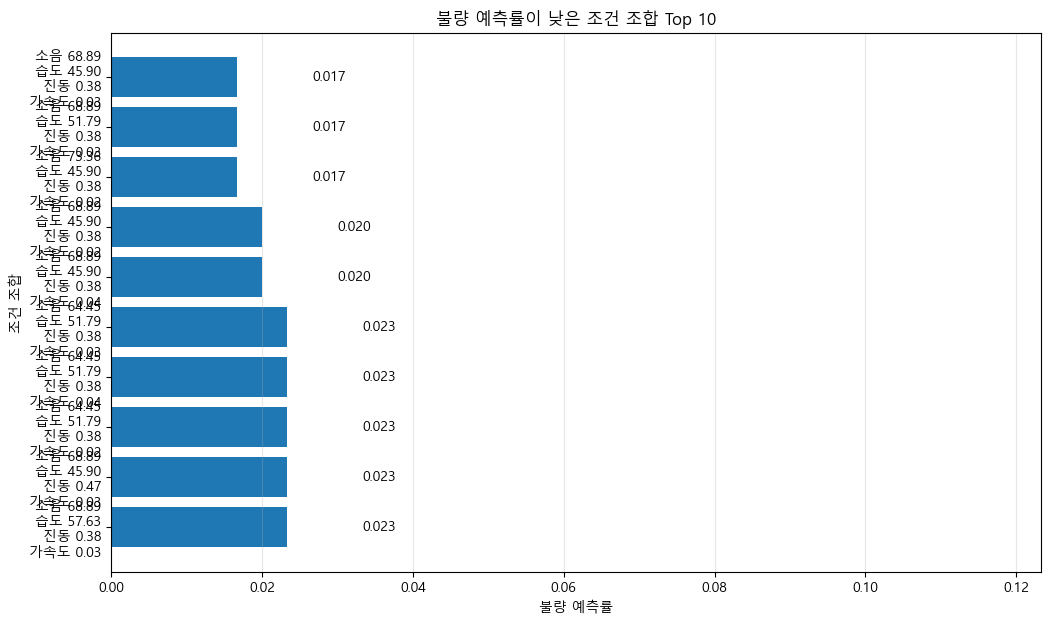

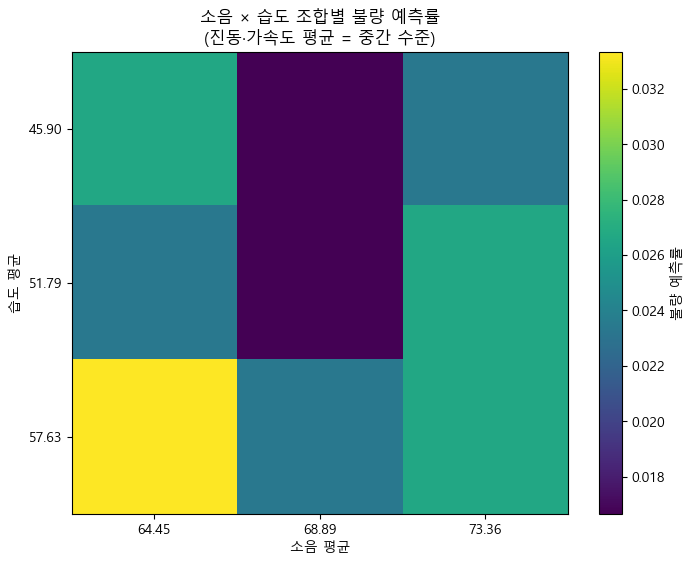

,변수,낮음,중간,높음
0,noise_mean,64.4515,68.8930,73.3600
1,humidity_mean,45.9020,51.7900,57.6280
2,vibration_mean,0.2882,0.3766,0.4677
3,acceleration_mean,0.0188,0.0277,0.0369


In [10]:
# =========================================================
# 1. 라이브러리
# =========================================================

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 2. 시뮬레이션 주요 변수 선정
# =========================================================

simulation_features = [
    "noise_mean",
    "humidity_mean",
    "vibration_mean",
    "acceleration_mean"
]


# =========================================================
# 3. 각 변수의 수준 설정
#    실제 데이터의 25%, 50%, 75% 분위수 사용
# =========================================================

levels = {
    "낮음": 0.25,
    "중간": 0.50,
    "높음": 0.75
}

feature_values = {}

for feature in simulation_features:

    feature_values[feature] = {
        level_name: df_file[feature].quantile(q)
        for level_name, q in levels.items()
    }


# =========================================================
# 4. 모든 변수 조합 생성
# =========================================================

level_names = ["낮음", "중간", "높음"]

combinations = list(
    itertools.product(
        level_names,
        repeat=len(simulation_features)
    )
)

print(f"총 시뮬레이션 조건 수: {len(combinations)}개")


# =========================================================
# 5. 시뮬레이션 데이터 생성
# =========================================================

simulation_data = []

for combination in combinations:

    row = {}

    for feature, level in zip(
        simulation_features,
        combination
    ):

        row[feature] = feature_values[
            feature
        ][level]

    simulation_data.append(row)


simulation_data = pd.DataFrame(
    simulation_data
)


# =========================================================
# 6. 모델 입력 데이터 생성
# =========================================================

X_simulation = pd.DataFrame(
    columns=features,
    index=range(len(simulation_data))
)


# 나머지 변수는 테스트 데이터 평균으로 고정
for feature in features:

    X_simulation[feature] = X_test[feature].mean()


# 주요 4개 변수는 시뮬레이션 값으로 대체
for feature in simulation_features:

    X_simulation[feature] = simulation_data[feature]


# =========================================================
# 7. 불량 예측확률 계산
# =========================================================

simulation_probability = model.predict_proba(
    X_simulation
)[:, 1]


simulation_data["불량 예측률"] = (
    simulation_probability
)


# =========================================================
# 8. 각 변수의 수준 표시
# =========================================================

for feature in simulation_features:

    q25 = feature_values[feature]["낮음"]
    q50 = feature_values[feature]["중간"]
    q75 = feature_values[feature]["높음"]

    simulation_data[
        f"{feature}_수준"
    ] = simulation_data[feature].apply(
        lambda x:
            "낮음" if np.isclose(x, q25)
            else "중간" if np.isclose(x, q50)
            else "높음"
    )


# =========================================================
# 9. 최종 시뮬레이션 결과표
# =========================================================

simulation_result = simulation_data[
    simulation_features +
    ["불량 예측률"]
].copy()


simulation_result = simulation_result.sort_values(
    "불량 예측률"
).reset_index(drop=True)


# 결과 확인
display(
    simulation_result.round(4)
)


# =========================================================
# 10. 불량 예측률이 낮은 조건 Top 10
# =========================================================

best_conditions = (
    simulation_result
    .head(10)
    .copy()
)


display(
    best_conditions.round(4)
)


# =========================================================
# 11. 불량 예측률이 낮은 조건 시각화
# =========================================================

condition_labels = []

for _, row in best_conditions.iterrows():

    label = (
        f"소음 {row['noise_mean']:.2f}\n"
        f"습도 {row['humidity_mean']:.2f}\n"
        f"진동 {row['vibration_mean']:.2f}\n"
        f"가속도 {row['acceleration_mean']:.2f}"
    )

    condition_labels.append(label)


plt.figure(figsize=(12, 7))

bars = plt.barh(
    condition_labels,
    best_conditions["불량 예측률"]
)

plt.xlabel("불량 예측률")
plt.ylabel("조건 조합")

plt.title(
    "불량 예측률이 낮은 조건 조합 Top 10"
)

plt.gca().invert_yaxis()

for bar, value in zip(
    bars,
    best_conditions["불량 예측률"]
):

    plt.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center"
    )

plt.xlim(
    0,
    min(
        1,
        best_conditions["불량 예측률"].max() + 0.1
    )
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.show()


# =========================================================
# 12. 소음 × 습도 조합 Heatmap
#    진동·가속도는 각각 중간 수준으로 고정
# =========================================================

heatmap_data = simulation_result[
    (
        simulation_result["vibration_mean"]
        == feature_values["vibration_mean"]["중간"]
    )
    &
    (
        simulation_result["acceleration_mean"]
        == feature_values["acceleration_mean"]["중간"]
    )
].copy()


heatmap = heatmap_data.pivot(
    index="humidity_mean",
    columns="noise_mean",
    values="불량 예측률"
)


plt.figure(figsize=(8, 6))

plt.imshow(
    heatmap.values,
    aspect="auto"
)

plt.xticks(
    range(len(heatmap.columns)),
    [f"{x:.2f}" for x in heatmap.columns]
)

plt.yticks(
    range(len(heatmap.index)),
    [f"{x:.2f}" for x in heatmap.index]
)

plt.xlabel("소음 평균")
plt.ylabel("습도 평균")

plt.title(
    "소음 × 습도 조합별 불량 예측률\n"
    "(진동·가속도 평균 = 중간 수준)"
)

plt.colorbar(
    label="불량 예측률"
)

plt.show()


# =========================================================
# 13. 각 변수의 실제 시뮬레이션 수준 확인
# =========================================================

level_table = pd.DataFrame({
    "변수": simulation_features,
    "낮음": [
        feature_values[f]["낮음"]
        for f in simulation_features
    ],
    "중간": [
        feature_values[f]["중간"]
        for f in simulation_features
    ],
    "높음": [
        feature_values[f]["높음"]
        for f in simulation_features
    ]
})

display(
    level_table.round(4)
)

## 처음 센서 변수의 기초 통계

In [11]:
# =========================================================
# 초기(개선 전) 주요 센서 변수의 기초 통계
# =========================================================

simulation_features = [
    "noise_mean",
    "humidity_mean",
    "vibration_mean",
    "acceleration_mean"
]

sensor_summary = df_file[simulation_features].describe().T[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
]

display(
    sensor_summary.round(4)
)

,mean,std,min,25%,50%,75%,max
noise_mean,69.8300,6.9477,60.00,64.4515,68.8930,73.3600,90.00
humidity_mean,52.9896,9.1579,40.00,45.9020,51.7900,57.6280,80.00
vibration_mean,0.3802,0.1087,0.20,0.2882,0.3766,0.4677,0.60
acceleration_mean,0.0281,0.0109,0.01,0.0188,0.0277,0.0369,0.05


#### **정리**

> || 기존 데이터 평균 ||

|                   |       mean |       std |   min |      25% |      50% |      75% |      max |
|:------------------|-----------:|----------:|------:|---------:|---------:|---------:|---------:|
| noise_mean        | 69.83      | 6.94769   | 60    | 64.4515  | 68.893   | 73.36    | 90       |
| humidity_mean     | 52.9896    | 9.15791   | 40    | 45.902   | 51.79    | 57.628   | 80       |
| vibration_mean    |  0.380238  | 0.108667  |  0.2  |  0.28818 |  0.37658 |  0.46766 |  0.59998 |
| acceleration_mean |  0.0280643 | 0.0109358 |  0.01 |  0.01884 |  0.0277  |  0.03692 |  0.05    |

> || 시뮬레이션 결과 ||

|   noise_mean |   humidity_mean |   vibration_mean |   acceleration_mean |   불량 예측률 |
|-------------:|----------------:|-----------------:|--------------------:|--------------:|
|      68.893  |          45.902 |          0.37658 |             0.0277  |     0.0166667 |
|      68.893  |          51.79  |          0.37658 |             0.0277  |     0.0166667 |
|      73.36   |          45.902 |          0.37658 |             0.01884 |     0.0166667 |
|      68.893  |          45.902 |          0.37658 |             0.01884 |     0.02      |
|      68.893  |          45.902 |          0.37658 |             0.03692 |     0.02      |
|      64.4515 |          51.79  |          0.37658 |             0.0277  |     0.0233333 |
|      64.4515 |          51.79  |          0.37658 |             0.03692 |     0.0233333 |
|      64.4515 |          51.79  |          0.37658 |             0.01884 |     0.0233333 |
|      68.893  |          45.902 |          0.46766 |             0.0277  |     0.0233333 |
|      68.893  |          57.628 |          0.37658 |             0.0277  |     0.0233333 |

## 시뮬레이션 결과 평가

- 4개 주요 센서의 평균값을 하·중·상으로 구분하여 **81개 조건을 조합**하고, 각 조건에 대한 Random Forest의 불량 예측률을 비교하였다.
- 불량 예측률이 낮은 상위 조건에서는 다음과 같은 경향이 나타났다.
  - 소음 평균: **중간 수준(68.893)**이 반복적으로 나타남
  - 습도 평균: **낮은 수준(45.902)과 중간 수준(51.79)**이 주로 나타남
  - 진동 평균: **중간 수준(0.37658)**이 대부분의 조건에서 나타남
  - 가속도 평균: **중간 수준(0.0277)**을 중심으로 다양한 수준이 나타나 뚜렷한 방향성은 확인되지 않음
- 불량 예측률이 가장 낮은 조건은 **소음 68.893, 습도 45.902, 진동 0.37658, 가속도 0.0277**이며, 이때 불량 예측률은 **1.67%**로 나타났다.
- 상위 10개 조건의 불량 예측률은 **1.67~2.33%**로 비교적 낮은 범위에 집중되었다.
- 전체적으로 **습도는 낮은 수준, 소음·진동·가속도는 중간 수준**에서 낮은 불량 예측률을 보이는 조건이 상대적으로 많이 나타났다.

## 결론

- 4개 센서의 하·중·상 조합을 이용한 시뮬레이션을 통해 **모델이 낮은 불량 예측률을 나타내는 공정 조건의 조합을 탐색**하였다.
- 그 결과, **습도는 낮은 수준, 소음·진동·가속도는 중간 수준**인 조건이 낮은 불량 예측률을 보이는 상위 조건에 반복적으로 나타났다.
- 특히 **소음 68.893, 습도 45.902, 진동 0.37658, 가속도 0.0277** 조합에서 가장 낮은 불량 예측률인 **1.67%**가 나타났다.
- 다만 본 결과는 **실제 공정에서 해당 조건을 적용했을 때 불량률이 감소한다는 것을 의미하지 않는다.** 81개 조건에 대한 Random Forest의 예측 결과를 비교한 것이므로, 실제 공정 적용을 위해서는 **실제 공정 데이터 또는 실험을 통한 추가 검증이 필요하다.**